In [16]:

from pathlib import Path

import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles

import seaborn as sns
import matplotlib.pylab as plt

In [15]:
from pathlib import Path

DATA_REPO = Path().cwd().parent.parent / "data"
COFFEE_SALES = DATA_REPO / "Coffe_sales.csv"

In [3]:
import pandas as pd

df = pd.read_csv(COFFEE_SALES)
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [4]:
money = df["money"]

print(money.mean())
print(money.median())

print(money.quantile(0.25))
print(money.quantile(0.01))

print(money.loc[money < money.quantile(0.01)])

31.64521567521849
32.82
27.92
19.472400000000004
888     18.12
935     18.12
938     18.12
952     18.12
957     18.12
974     18.12
976     18.12
984     18.12
1006    18.12
1015    18.12
1067    18.12
1104    18.12
1111    18.12
1148    18.12
1158    18.12
1182    18.12
1199    18.12
1206    18.12
1211    18.12
1212    18.12
1240    18.12
1281    18.12
1282    18.12
1312    18.12
1378    18.12
1381    18.12
1382    18.12
1393    18.12
1394    18.12
1398    18.12
1401    18.12
1423    18.12
1448    18.12
1468    18.12
1492    18.12
1601    18.12
Name: money, dtype: float64


In [5]:
HOUSES_DATA = DATA_REPO / "Housing.csv"
df = pd.read_csv(HOUSES_DATA)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
print(df["price"].mean())
print(df["price"].median())

from scipy.stats import trim_mean

print(trim_mean(df["price"], 0.1))  



4766729.247706422
4340000.0
4559299.42791762


In [19]:
print(df["price"].std())
print(df["price"].quantile(0.75) - df["price"].quantile(0.25))

1870439.6156573922
2310000.0


1556732.3294308821
536    1960000
537    1890000
538    1890000
539    1855000
540    1820000
541    1767150
542    1750000
543    1750000
544    1750000
Name: price, dtype: int64
9
536    1960000
537    1890000
538    1890000
539    1855000
540    1820000
541    1767150
542    1750000
543    1750000
544    1750000
Name: price, dtype: int64
0.01651376146788991


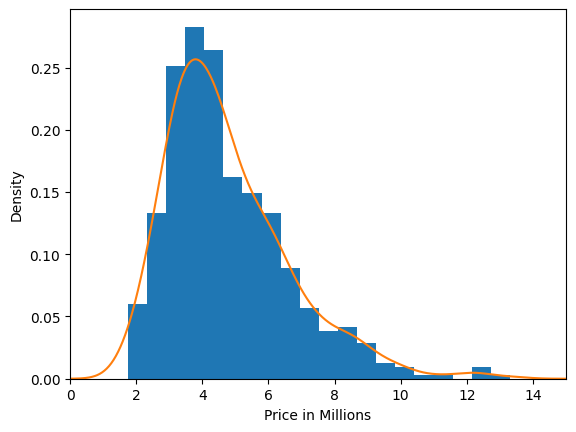

In [64]:
print(robust.mad(df["price"]))

price_mils = df["price"] / 1_000_000 
ax = price_mils.plot.hist(density=True, bins=20, xlim=[0,15])
price_mils.plot.density(ax=ax)
ax.set_xlabel("Price in Millions")


def get_length_underqr_elements(quartile: float, show_entries: bool) -> int:
    qrt_df = df["price"].loc[df["price"] < df["price"].quantile(quartile)]

    if show_entries:
        print(qrt_df)
    
    return len(qrt_df.index)

print(get_length_underqr_elements(0.02, True))
print(get_length_underqr_elements(0.02, True) / len(df.index))

<Axes: >

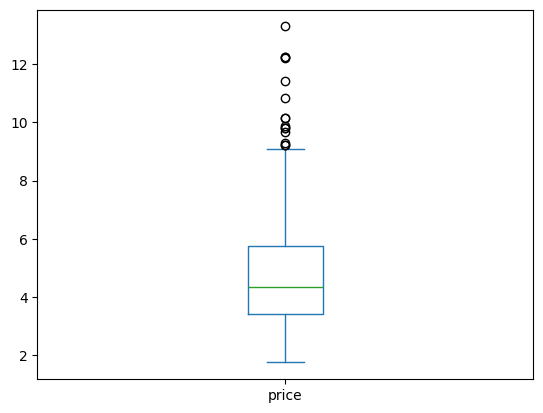

In [65]:
price_mils.plot.box()
